In [36]:
%pip install statsmodels --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
  Using cached statsmodels-0.14.6-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (9.5 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached statsmodels-0.14.6-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (10.3 MB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)
Note: you may need to restart the kernel to use updated packages.


In [19]:
import pandas as pd
from scipy import stats
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
## standardize the dataset Train independent data
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error
import matplotlib.pyplot as plt

In [20]:
#Load the data
df = pd.read_csv("Salary_dataset.csv")
print(df)

# 2. Define the two fields you want to test
fields_to_test = ['YearsExperience', 'Salary']

# 3. Standardize the data
# StandardScaler expects a 2D array, so we use df[fields_to_test]
# StandardScaler: It automatically shifts the mean of each column to 0 and the standard deviation to 1. 
# This matches the default 'norm' distribution in scipy.stats.kstest
scaler = StandardScaler()
# We dropna() to ensure the test doesn't fail due to missing values
scaled_data = scaler.fit_transform(df[fields_to_test].dropna())

# 4. Run KS-Test for each field
# A Quick Note on the P-Value:
#If you see a very small p-value (e.g., 1.23e-10), it means your data is significantly different from a normal distribution. 
# If the p-value is large (e.g., 0.45), the data is likely normal.

for i, column_name in enumerate(fields_to_test):
    # Extract the specific scaled column (scaled_data is a numpy array)
    data_column = scaled_data[:, i]
    
    # Perform K-S test against the standard normal distribution ('norm')
    ks_stat, p_value = stats.kstest(data_column, 'norm')
    
    print(f"--- Results for: {column_name} ---")
    print(f"K-S Statistic: {ks_stat:.4f}")
    print(f"P-Value: {p_value:.4e}")
    
    # Interpretation
    alpha = 0.05
    if p_value < alpha:
        print("Result: Reject Null Hypothesis (Data is NOT normally distributed)")
    else:
        print("Result: Fail to Reject Null Hypothesis (Data looks normally distributed)")
    print("\n")

    Unnamed: 0  YearsExperience    Salary
0            0              1.2   39344.0
1            1              1.4   46206.0
2            2              1.6   37732.0
3            3              2.1   43526.0
4            4              2.3   39892.0
5            5              3.0   56643.0
6            6              3.1   60151.0
7            7              3.3   54446.0
8            8              3.3   64446.0
9            9              3.8   57190.0
10          10              4.0   63219.0
11          11              4.1   55795.0
12          12              4.1   56958.0
13          13              4.2   57082.0
14          14              4.6   61112.0
15          15              5.0   67939.0
16          16              5.2   66030.0
17          17              5.4   83089.0
18          18              6.0   81364.0
19          19              6.1   93941.0
20          20              6.9   91739.0
21          21              7.2   98274.0
22          22              8.0  1

Important Warning: The "Estimated Parameter" Problem
Standardizing your data using its own mean and standard deviation (or passing them as arguments) technically violates the assumptions of the standard K-S test because you are "forcing" the reference distribution to match your data. This can make the resulting p-values too high (less likely to detect non-normality). 
Stack Exchange
Stack Exchange
 +1
Better Alternatives for Normality:
For small/medium samples (
): Use the Shapiro-Wilk test (stats.shapiro(data)). It does not require standardization and is generally more powerful for testing normality.
For cases where you must estimate parameters: Use the Lilliefors test (statsmodels.stats.diagnostic.kstest_normal), which is a version of the K-S test specifically adjusted for when the mean and variance are unknown

(24, 1) (6, 1) (24,) (6,)
X_train:  [[ 1.77445774]
 [ 1.21912622]
 [-0.41216011]
 [-1.41869849]
 [-1.03690807]
 [-0.03036969]
 [-0.79395053]
 [-0.37745189]
 [-0.41216011]
 [ 0.94146047]
 [-1.34928205]
 [-1.27986561]
 [ 1.32325088]
 [-1.10632451]
 [ 0.66379471]
 [ 1.49679198]
 [ 0.24729607]
 [ 1.84387418]
 [ 0.55967005]
 [-0.68982587]
 [-0.44686833]
 [-0.23861901]
 [ 0.28200429]
 [-0.75924231]]
The slope or coefficient of weight is:  [27151.53742583]
Intercept: 74208.625


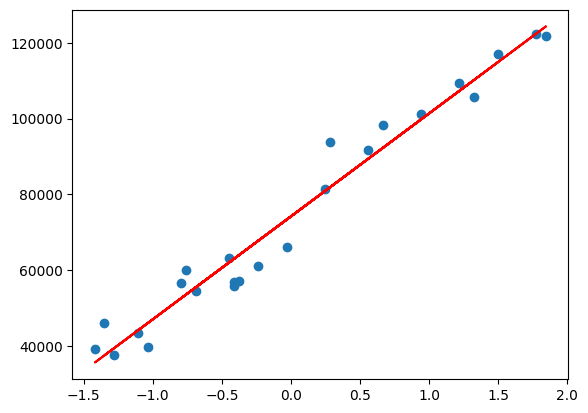

y_pred_test:  [115791.21011287  71499.27809463 102597.86866063  75268.80422384
  55478.79204548  60190.69970699]
y_test:  27    112636.0
15     67939.0
23    113813.0
17     83089.0
8      64446.0
9      57190.0
Name: Salary, dtype: float64


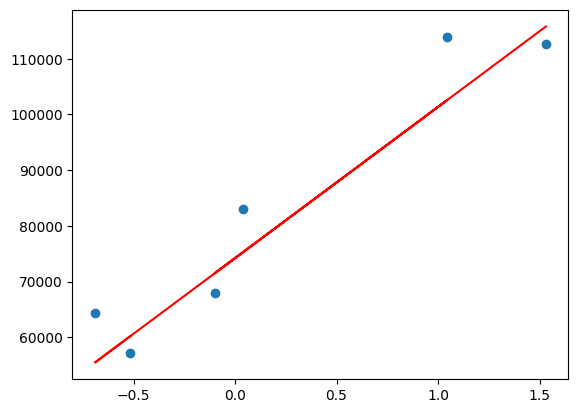

In [30]:
# Divide our dataset into dependent and independent features.
X = df[["YearsExperience"]] # independent feature
y = df["Salary"] # dependent feature

# X_train - input feature for my training dataset
# y_train - output feature for my training dataset
# X_test - input feature for my test dataset
# y_test - output feature for my test dataset
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
scaler = StandardScaler()
#print(X_train.head())
# fit_transform will apply z-score on every data point of X_train. In order to find the z-score
# we required mean and standard deviation. So, fit will compute the mean and standard deviation
# and transform will apply the z-score formula on every data point.
X_train=scaler.fit_transform(X_train)
print("X_train: ",X_train)
# For training data above we need to do fit_transform
# for test data we only need to do transform. because my model should not know anything about
# the test data. It should only have the information about the training data.
# The transform function does not calculate a mean or standard deviation for the test data; instead, it reuses the 
# statistical parameters that were already calculated and stored during the fit call on the training data.
X_test=scaler.transform(X_test)
# This model will helps in finding the best intercept and also all the slopes of the independent
# features while training the data.
regressor = LinearRegression()
regressor.fit(X_train, y_train) # X_train - independent feature, y_train - dependent feature.
# The .fit() method uses the provided data to find the optimal coefficients (slopes) and the intercept for the linear equation. 
# Essentially, it's learning the best-fit line or hyperplane that minimizes the error between its predictions and the actual values 
# in the training data.
print("The slope or coefficient of weight is: ",regressor.coef_)
print("Intercept:",regressor.intercept_)
# Checking the linearity by checking scatter plot
plt.scatter(X_train,y_train)
plt.plot(X_train,regressor.predict(X_train),'r')
plt.show()
# Let's do predition now on test data, now how to understand that my prediction are correct
y_pred_test=regressor.predict(X_test)
print("y_pred_test: ", y_pred_test)
print("y_test: ",y_test)
plt.scatter(X_test,y_test)
plt.plot(X_test, regressor.predict(X_test), 'r')
plt.show()

In [26]:
##To evaluate how well your model performs on both the training and test datasets, you should calculate performance metrics 
##for both sets and compare them. The two most common metrics for this are R-squared (\(R^{2}\)), which measures how much 
#variance the model explains, and Mean Squared Error (MSE), which measures the average error. 

## Performance Metrics

## MSE,MAE,RMSE
## R square and adjusted R square

In [31]:
#This section provides "Hard Numbers" to measure error magnitude and fit. Mean Squared Error (MSE) & RMSE: These measure the 
#average error distance between actual and predicted heights. Because MSE is squared (e.g., \(inches^{2}\)), RMSE (Root MSE) 
#is often easier to understand because it uses the same units as your target (e.g., if RMSE is 2.5, your predictions are typically 
#off by 2.5 inches).R-Squared (\(R^{2}\)): This ranges from 0 to 1. An \(R^{2}\) of 0.85 means your model explains 85% of the salary 
#variation based on year of experience. 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predictions for both sets to check for Overfitting
#y_pred_train = regressor.predict(X_train)
#y_pred_test = regressor.predict(X_test)

# Metrics for Test Data
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
score = r2_score(y_test, y_pred_test)

print(f"Test MSE: {mse}")
print(f"Test MAE: {mae}")
print(f"Test RMSE: {rmse}")
print(f"Test R-squared: {score}")


Test MSE: 49830096.85590836
Test MAE: 6286.453830757742
Test RMSE: 7059.043621901507
Test R-squared: 0.9024461774180498


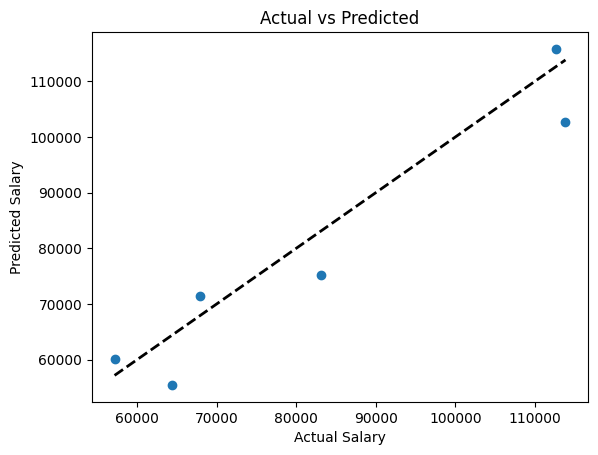

In [32]:
#Visual Validation (The "Residual" Plot)
#A model is "correct" if its errors are random. If you see a pattern in the errors, your model is missing something.
#Interpretation: If the dots fall close to the diagonal line, your predictions are highly accurate.
plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Diagonal line
plt.show()


#Check overfitting below
Compare the performance on training data vs. test data.
Good: High R2 on both Train and Test.
Overfitting: High R2 on Train, but very low R2 on Test (the model just memorized the training data).


In [33]:
from sklearn.metrics import r2_score

# 1. Predict for both sets
y_pred_train = regressor.predict(X_train)
y_pred_test = regressor.predict(X_test)

# 2. Calculate R2 Scores
train_score = r2_score(y_train, y_pred_train)
test_score = r2_score(y_test, y_pred_test)

print(f"Training R2 Score: {train_score:.4f}")
print(f"Testing R2 Score:  {test_score:.4f}")

# 3. Analyze the gap
diff = train_score - test_score
if diff > 0.10: # Generally, a gap larger than 10% suggests overfitting
    print(f"Warning: Potential Overfitting. Gap: {diff:.4f}")
elif diff < 0 and abs(diff) > 0.10:
    print(f"Warning: Potential Underfitting or Data Split issue. Gap: {diff:.4f}")
else:
    print("The model is generalized well (Good fit).")


Training R2 Score: 0.9645
Testing R2 Score:  0.9024
The model is generalized well (Good fit).


In [34]:
# checking correlation
# Pearson correlation coefficient
correlation = df[["YearsExperience", "Salary"]].corr().iloc[0,1]
print(f"Pearson Correlation (r): {correlation:.4f}")


Pearson Correlation (r): 0.9782


In [37]:
# ANOVA and Statistical Summary
#In Linear Regression, the ANOVA F-test checks if the independent variable (YearsExperience) significantly explains the variance 
#in the dependent variable (Salary) compared to a model with no predictors.

import statsmodels.api as sm

# statsmodels requires an explicit intercept (constant)
X_train_stat = sm.add_constant(X_train)
model_stat = sm.OLS(y_train, X_train_stat).fit()

# Print the full summary (includes ANOVA results)
print(model_stat.summary())


                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.963
Method:                 Least Squares   F-statistic:                     598.4
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           1.91e-17
Time:                        22:56:03   Log-Likelihood:                -239.44
No. Observations:                  24   AIC:                             482.9
Df Residuals:                      22   BIC:                             485.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7.421e+04   1109.919     66.859      0.0